# SHAP-Based Patient-Level Explanation of Mortality Risk Predictions

In [90]:
import joblib
import shap
import pandas as pd
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.metrics import (confusion_matrix, classification_report)
import matplotlib.pyplot as plt

# Load Saved Models and Data

In [11]:
# We load our best models
best_logistic_model = joblib.load("../machine learning modeling/best_logistic_model.pkl")
best_model_gb = joblib.load("../machine learning modeling/best_gradient_boosting_model.pkl")
X_train = joblib.load("../machine learning modeling/X_train.pkl")
X_test = joblib.load("../machine learning modeling/X_test.pkl")
y_train = joblib.load("../machine learning modeling/y_train.pkl")
y_test = joblib.load("../machine learning modeling/y_test.pkl")

In [12]:
print(type(best_logistic_model))
print(type(best_model_gb))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


This shows the saved models are pipeline. So, we double check the pipeline steps.

In [14]:
if isinstance(best_logistic_model, Pipeline):
    print("Logistic Pipeline Steps:", best_logistic_model.named_steps.keys())

if isinstance(best_model_gb, Pipeline):
    print("Gradient Boosting Pipeline Steps:", best_model_gb.named_steps.keys())

Logistic Pipeline Steps: dict_keys(['preprocessor', 'classifier'])
Gradient Boosting Pipeline Steps: dict_keys(['preprocessor', 'classifier'])


We separate the preprocessing step from the estimator (classifier) so SHAP explainer sees the transformed features that the classifier uses.

In [16]:
def split_pipeline(model):
    if isinstance(model, Pipeline):
        preprocessor = Pipeline(model.steps[:-1]) # returns everything but the last item in the pipeline
        estimator = model.steps[-1][1]
        return preprocessor, estimator

    return None, model

log_preprocess, log_estimator = split_pipeline(best_logistic_model)
gb_preprocess, gb_estimator = split_pipeline(best_model_gb)

In [17]:
print(log_estimator)

LogisticRegression(C=0.03, class_weight='balanced', max_iter=1000, penalty='l2',
                   random_state=42)


In [18]:
print(gb_estimator)

HistGradientBoostingClassifier(class_weight='balanced', early_stopping=True,
                               l2_regularization=np.float64(1.025616274847307),
                               learning_rate=np.float64(0.012502377950801122),
                               max_features=0.6, max_iter=847,
                               max_leaf_nodes=77, n_iter_no_change=20,
                               random_state=42, validation_fraction=0.15)


# Prepare Data for SHAP

We start by defining functions that will help us transform our data

In [21]:
# After preprocessing, the transformed matrix may be a sparse matrix,
# which is not preferred for ploting, so we convert to dense matrix

def to_dense(X):
    if hasattr(X, "toarray"):        #sparse matrix has method "toarray" attributes
        return X.to_array()         # converts to dense arrays
    return X
        

def get_feature_names(preprocess, X_raw):
    """ We will try to extract the feature names and clean it, and if it fails we resort to default names"""
    try:
        names = preprocess.get_feature_names_out()
    except Exception:
        names = [f"feature_{i}" for i in range(preprocess.transform(X_raw).shape[1])]

    cleaned = []
    for name in names:
        cleaned_name = str(name)
        cleaned_name = cleaned_name.replace("num__", "")
        cleaned_name = cleaned_name.replace("cat__", "")
        cleaned_name = cleaned_name.replace("numeric__","")
        cleaned.append(cleaned_name)
    return cleaned

print(get_feature_names(gb_preprocess, X_train))

['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']


We are now ready to transform our X_train and X_test into a form most compatible for SHAP

In [23]:
# We transform X_train and X_test data to be in the same format that our selected models sees them.
if log_preprocess is not None:     # means log_preprocess is in a pipeline
    X_train_log_array = to_dense(log_preprocess.transform(X_train))
    X_test_log_array = to_dense(log_preprocess.transform(X_test))
    log_feature_names = get_feature_names(log_preprocess, X_train)
else:    # we use the original data if not.
    X_train_log_array = X_train.values
    X_test_log_array = X_test.values
    log_feature_names = X_train.columns.tolist()

# We put the transformed data into a data frame for easier ploting using SHAP.

X_train_log = pd.DataFrame(X_train_log_array,
                           columns = log_feature_names,
                           index = X_train.index)

X_test_log = pd.DataFrame(X_test_log_array, columns= log_feature_names, index = X_test.index)
    

In [24]:
X_train_log.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
115,-0.269050,-0.200735,0.176528,-1.004722,-0.360437,0.559915,1.0,0.0,0.0,0.0,0.0
23,-0.706883,-0.534318,1.847425,1.051685,-0.544467,-0.345802,0.0,1.0,0.0,1.0,0.0
0,1.219579,-0.020580,-1.494369,0.013401,0.467698,-1.477949,0.0,0.0,1.0,1.0,0.0
247,0.256348,-0.455129,-1.076645,-0.178127,0.927773,-0.345802,0.0,0.0,0.0,1.0,0.0
194,-1.407414,-0.020580,-1.494369,-1.387778,0.191653,-0.345802,0.0,0.0,1.0,1.0,0.0


In [25]:
X_test_log.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
274,-0.093917,-0.342285,-0.658921,-1.145848,-0.360437,0.107057,1.0,1.0,0.0,1.0,1.0
149,-0.093917,1.641397,-0.241196,-0.359574,-0.452452,-0.119373,0.0,0.0,1.0,1.0,0.0
120,-0.093917,0.132848,1.847425,-0.541022,0.099638,-0.345802,1.0,0.0,1.0,1.0,1.0
226,-0.269050,-0.540257,-1.076645,-0.752711,-0.084392,-1.025090,1.0,0.0,0.0,1.0,1.0
125,-1.582547,-0.242309,1.011976,-0.268851,-0.084392,-0.345802,1.0,0.0,0.0,0.0,0.0


In [26]:
print(X_train_log.shape)
print(X_test_log.shape)

(239, 11)
(60, 11)


Gradient boosting transformed data

In [28]:
if gb_preprocess is not None:
    X_train_gb_array = to_dense(gb_preprocess.transform(X_train))
    X_test_gb_array = to_dense(gb_preprocess.transform(X_test))
    gb_feature_names = get_feature_names(gb_preprocess, X_train)

else:
    X_train_gb_array = X_train.values
    X_test_gb_array = X_test.values
    gb_feature_names = X_train.columns.tolist()


X_train_gb = pd.DataFrame(X_train_gb_array, 
                          columns = gb_feature_names,
                          index= X_train.index)

X_test_gb = pd.DataFrame(X_test_gb_array,
                         columns = gb_feature_names,
                         index = X_test.index)



In [29]:
print(X_train_gb.shape)
print(X_test_gb.shape)

(239, 11)
(60, 11)


In [30]:
X_train_gb.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
115,58.0,400.0,40.0,164000.0,1.0,139.0,1.0,0.0,0.0,0.0,0.0
23,53.0,63.0,60.0,368000.0,0.8,135.0,0.0,1.0,0.0,1.0,0.0
0,75.0,582.0,20.0,265000.0,1.9,130.0,0.0,0.0,1.0,1.0,0.0
247,64.0,143.0,25.0,246000.0,2.4,135.0,0.0,0.0,0.0,1.0,0.0
194,45.0,582.0,20.0,126000.0,1.6,135.0,0.0,0.0,1.0,1.0,0.0


In [31]:
X_test_gb.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
274,60.0,257.0,30.0,150000.0,1.0,137.0,1.0,1.0,0.0,1.0,1.0
149,60.0,2261.0,35.0,228000.0,0.9,136.0,0.0,0.0,1.0,1.0,0.0
120,60.0,737.0,60.0,210000.0,1.5,135.0,1.0,0.0,1.0,1.0,1.0
226,58.0,57.0,25.0,189000.0,1.3,132.0,1.0,0.0,0.0,1.0,1.0
125,43.0,358.0,50.0,237000.0,1.3,135.0,1.0,0.0,0.0,0.0,0.0


## Re-evaluate the models performance before explaining their predictions using SHAP

In [33]:
def evaluate_model(model, X_test_raw, y_test, label):
    y_test_pred = model.predict(X_test_raw)
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test_raw)[:,1]

    else:
        y_test_prob = np.repeat(np.nan, len(y_test))

    print(f"\n======================{label}===========================================")
    print(confusion_matrix(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred, target_names=["no_death_event", "death_event"], zero_division=0))
    
    return pd.DataFrame({"actual":y_test, "predicted": y_test_pred,
                         "proba_death": y_test_prob}, index= X_test_raw.index).head(10)
    

In [34]:
log_results = evaluate_model(best_logistic_model, X_test, y_test, "Tuned Logistic Regression")
log_results


======================Tuned Logistic Regression===========================================
[[32  9]
 [ 5 14]]
                precision    recall  f1-score   support

no_death_event       0.86      0.78      0.82        41
   death_event       0.61      0.74      0.67        19

      accuracy                           0.77        60
     macro avg       0.74      0.76      0.74        60
  weighted avg       0.78      0.77      0.77        60



,actual,predicted,proba_death
274,0,1,0.515578
149,0,0,0.499491
120,0,0,0.346857
226,0,1,0.577249
125,0,0,0.277612
298,0,0,0.317515
130,0,0,0.258148
110,1,0,0.389353
275,0,0,0.308861
190,0,1,0.654949


In [35]:
gb_results = evaluate_model(best_model_gb, X_test, y_test, "Tuned Gradient Boosting")
gb_results


======================Tuned Gradient Boosting===========================================
[[31 10]
 [ 5 14]]
                precision    recall  f1-score   support

no_death_event       0.86      0.76      0.81        41
   death_event       0.58      0.74      0.65        19

      accuracy                           0.75        60
     macro avg       0.72      0.75      0.73        60
  weighted avg       0.77      0.75      0.76        60



,actual,predicted,proba_death
274,0,0,0.467760
149,0,0,0.176152
120,0,0,0.473181
226,0,1,0.797141
125,0,0,0.232733
298,0,1,0.558085
130,0,0,0.206276
110,1,1,0.535558
275,0,0,0.228248
190,0,1,0.863857


## SHAP explainer for the logistic regression model

In [37]:
# we create a representative background sample. We can actually use the whole training set since our dataset is small

log_background = X_train_log

In [38]:
log_explainer = shap.LinearExplainer(log_estimator, log_background)

Background dataset has 239 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=239 when initializing the masker.


In [62]:
log_exp = log_explainer(X_test_log)
log_exp.values.shape

(60, 11)

We now focus on explaining log_estimator's prediction on death event class (class 1) using SHAP

In [66]:
# we define this just incase our explainer is 3 dimensional (in our case is not)

def postive_class_explanation(exp, class_index):
    if len(exp.values.shape) == 3:  # (no of patients, no of features, no of classes); 3 dimension
        return exp[:,:, class_index]
    return exp   # this returns the logodds of class 1

log_exp_death = postive_class_explanation(log_exp, class_index = 1)  
log_exp_death.values.shape

(60, 11)

### Global feature importance using SHAP

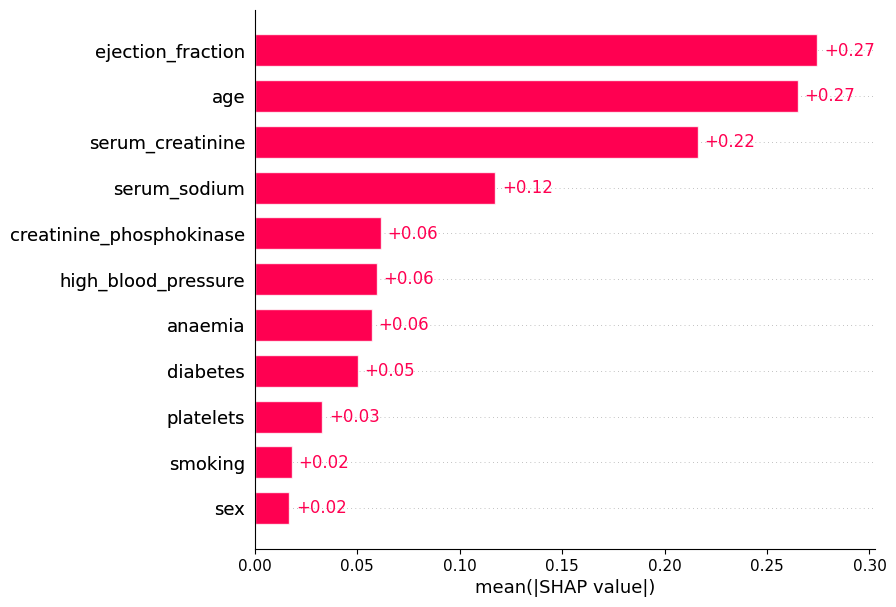

In [71]:
shap.plots.bar(log_exp_death, max_display=12)

The global shap bar plot for the Logistic Regression model shows that ejection fraction, patients age, and serum_creatine were the most influential features in the model's mortality risk predictions. This shows that the model relied heavily most heavily on heart pumping functions, patient age, and kidney-function-related information when estimating patient's death-event risk. Serum sodium also has moderate contribution while the remaining features had mild effects.

Text(0.5, 0, 'SHAP value: negative = toward no death event (0), postive = toward Death Event (1)')

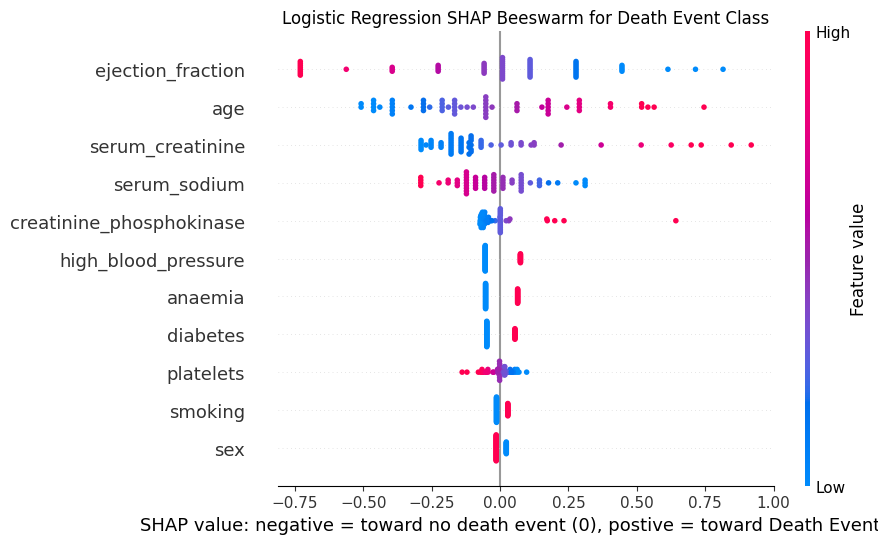

In [96]:
shap.plots.beeswarm(log_exp_death, max_display =12, show = False)
plt.title("Logistic Regression SHAP Beeswarm for Death Event Class")
plt.xlabel("SHAP value: negative = toward no death event (0), postive = toward Death Event (1)")

The beeswarm plot shaows that low ejection fraction appears more on the right, meaning that they push the model toward predicting death event. Also higher ejection fraction also appeared on the left, meaning that higher ejection fraction tends to push the model away from predicting death event.
On the other hand, higher age and higher serum creatine appeared more on the right, which means that higher age and higher values of serum creatine pushes the model to predict death event. Lower age and lower serum creatinine appeared on the left, meaning that they tend to push the model's prediction away from death event class. 

### Patient level waterfall plot

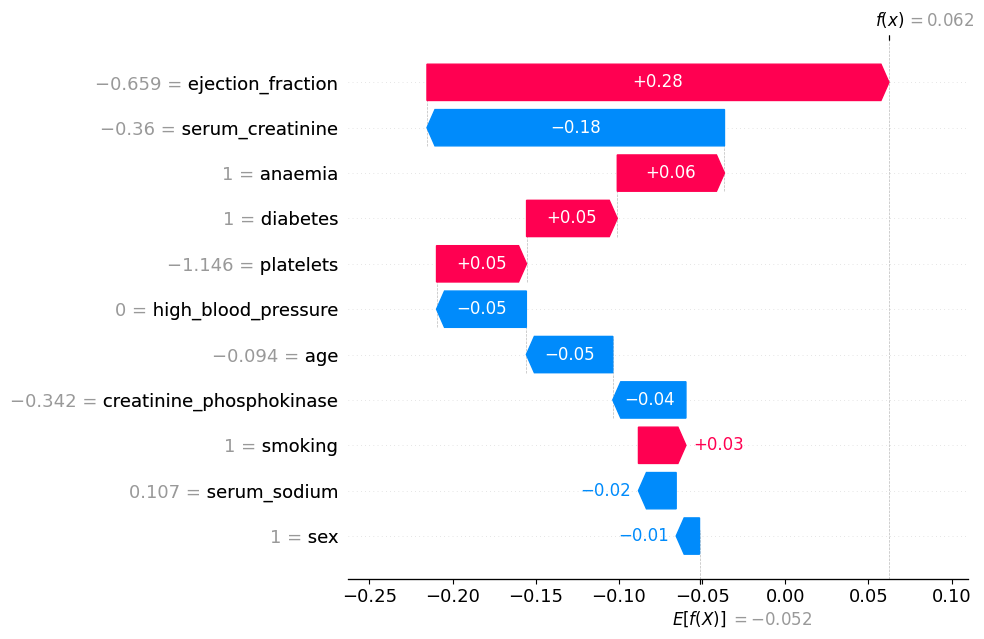

In [99]:
patient_pos = 0
shap.plots.waterfall(log_exp_death[patient_pos], max_display = 12)

The waterfall plot shows the main factors that influenced the logistic regression model’s prediction for patient 0. Features such as ejection fraction, anaemia status, diabetes status, platelet count, and smoking habit increased the model’s prediction toward the death event class. On the other hand, serum creatinine, high blood pressure, age, and creatinine phosphokinase decreased the model’s prediction, pushing it away from the death event class.

## SHAP for Gradient Boosting Model 

In [138]:
gb_background = X_train_gb.sample(n= min(100, len(X_train_gb)), random_state = 42)

In [140]:
try:
    gb_explainer = shap.TreeExplainer(gb_estimator, data= gb_background, model_output= "probability")
    gb_exp = gb_explainer(X_test_gb)

except Exception as e:
    """if probability fails we resort to raw explanation """
    print("Probability explanation failed. Resorting to raw explanation")
    print(e)
    gb_explainer = shap.TreeExplainer(gb_estimator, data = gb_background, model_output = "raw")
    gb_exp = gb_explainer(X_test_gb)
    
print(gb_exp.values.shape)

(60, 11)


In [142]:
gb_exp_death = postive_class_explanation(gb_exp, class_index = 1)
print(gb_exp_death.values.shape)

(60, 11)


We visualize top most influential features driving the gradient boosting model's prediction

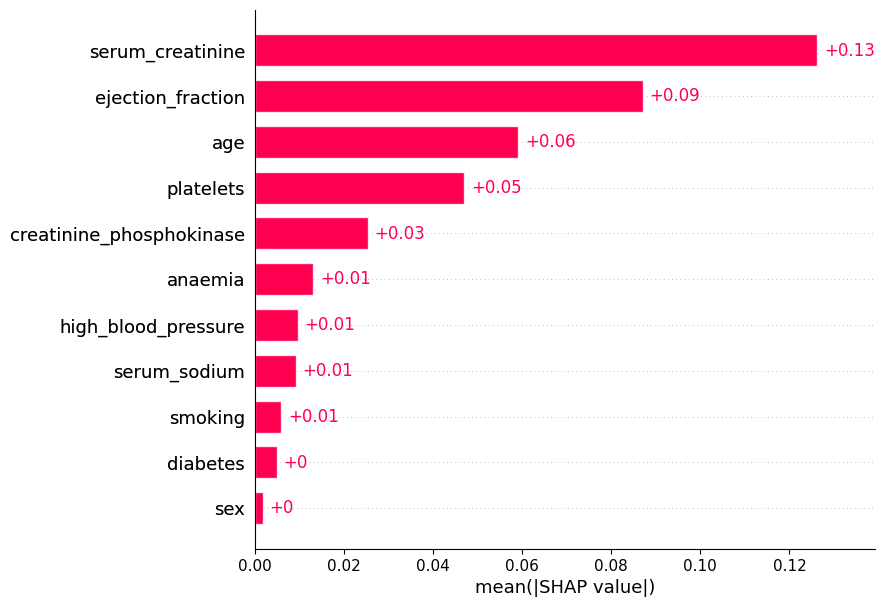

In [145]:
shap.plots.bar(gb_exp_death, max_display=12)

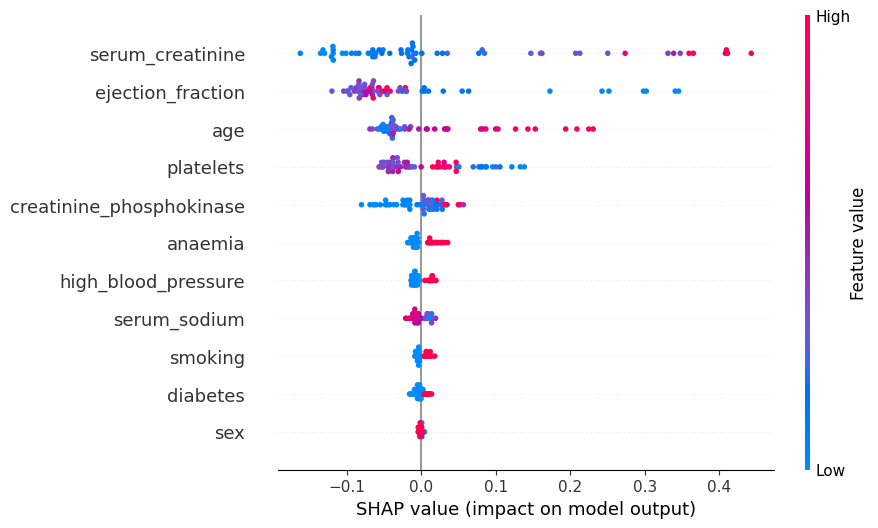

In [147]:
shap.plots.beeswarm(gb_exp_death, max_display=12)

Patient Level Explanation using SHAP waterfall plot

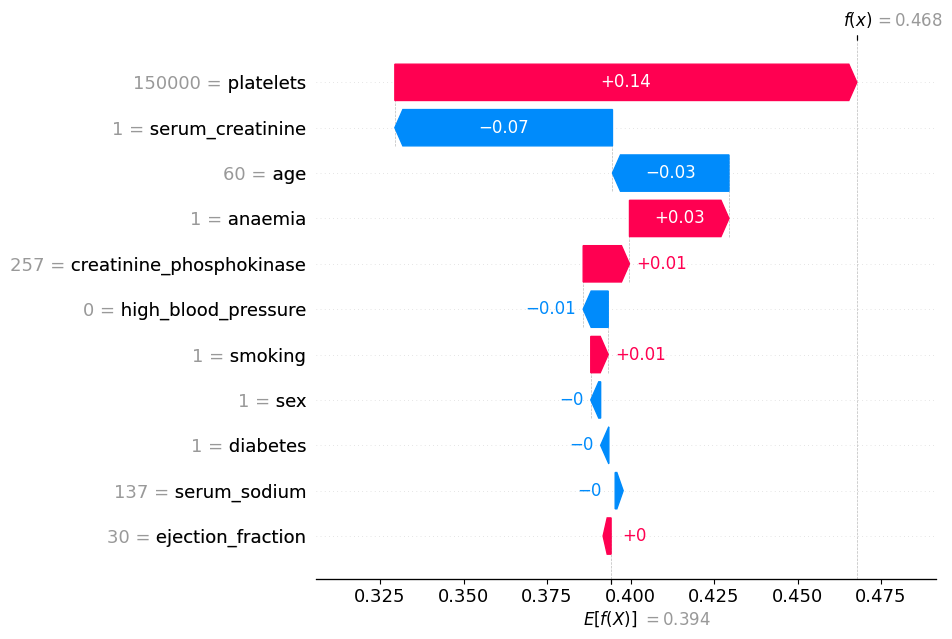

In [150]:
patient_pos = 0
shap.plots.waterfall(gb_exp_death[patient_pos], max_display =12)